# V3 Gender-Adversarial Debiasing for Ethnicity Classification



In [8]:
from copy import deepcopy
from pathlib import Path
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


PyTorch: 2.6.0+cu126
Device: cuda


In [9]:
# Locate the same project and metadata used by the source notebook.
cwd = Path.cwd().resolve()
candidates = [cwd / "project", cwd, *[p / "project" for p in cwd.parents]]
PROJECT_ROOT = next(
    p for p in candidates
    if (p / "data" / "processed" / "utkface_metadata.csv").exists()
)
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "utkface_metadata.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "ethnicity_v3_gender_debiasing"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.parent))
from project.src.data import load_metadata

metadata = load_metadata(METADATA_PATH)
required = {"image_path", "race_id", "gender_id", "gender", "split"}
missing = required.difference(metadata.columns)
if missing:
    raise ValueError(f"Missing metadata columns: {sorted(missing)}")

print("Project root:", PROJECT_ROOT)
display(metadata["split"].value_counts().reindex(["train", "val", "test"]).to_frame("images"))


Project root: D:\work\extra\diversification\project


,images
split,
train,16593
val,3556
test,3556


## Labels and experimental controls

The four targets exactly preserve the source notebook: `Other` combines
UTKFace `Asian` and `Others`. Validation and test retain their natural
distributions. Only the training loader is class-balanced.


In [10]:
MERGED_NAME_BY_RACE_ID = {
    0: "USA",      # White
    1: "Africa",   # Black
    2: "Other",    # Asian
    3: "India",    # Indian
    4: "Other",    # Others
}
CLASS_NAMES = ["USA", "Africa", "India", "Other"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
LABEL_BY_RACE_ID = {
    race_id: CLASS_TO_ID[name]
    for race_id, name in MERGED_NAME_BY_RACE_ID.items()
}
GENDER_NAMES = {0: "Male", 1: "Female"}

metadata = metadata.copy()
metadata["merged_class"] = metadata["race_id"].astype(int).map(MERGED_NAME_BY_RACE_ID)
metadata["target"] = metadata["race_id"].astype(int).map(LABEL_BY_RACE_ID).astype(int)
metadata["gender_id"] = metadata["gender_id"].astype(int)
if not set(metadata["gender_id"].unique()).issubset(GENDER_NAMES):
    raise ValueError("Expected binary UTKFace gender_id values 0 and 1.")

split_frames = {
    split: metadata.loc[metadata["split"] == split].reset_index(drop=True)
    for split in ("train", "val", "test")
}
display(pd.crosstab(metadata["merged_class"], metadata["gender"], margins=True))


gender,Female,Male,All
merged_class,,,
Africa,2208,2318,4526
India,1714,2261,3975
Other,2791,2335,5126
USA,4601,5477,10078
All,11314,12391,23705


## Stronger input pipeline

- **Normalization:** ImageNet channel statistics.
- **Augmentation:** random horizontal flip after a fixed resize, applied
  only to training images. This lightweight pipeline keeps repeated λ
  experiments practical in Windows notebook environments.
- **Class balancing:** inverse-frequency weighted sampling with replacement,
  applied only to the training loader. This avoids changing validation/test
  prevalence and avoids double-correcting with a second class-weighted loss.


In [11]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class EthnicityGenderDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")
        return (
            self.transform(image),
            torch.tensor(int(row["target"]), dtype=torch.long),
            torch.tensor(int(row["gender_id"]), dtype=torch.long),
        )


datasets = {
    "train": EthnicityGenderDataset(split_frames["train"], train_transform),
    "val": EthnicityGenderDataset(split_frames["val"], eval_transform),
    "test": EthnicityGenderDataset(split_frames["test"], eval_transform),
}

train_targets = split_frames["train"]["target"].to_numpy()
class_counts = np.bincount(train_targets, minlength=len(CLASS_NAMES))
sample_weights = torch.as_tensor(1.0 / class_counts[train_targets], dtype=torch.double)

def make_train_loader(seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator,
    )
    return DataLoader(
        datasets["train"], batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
    )

eval_loaders = {
    split: DataLoader(
        datasets[split], batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
    )
    for split in ("val", "test")
}
display(pd.DataFrame({"class": CLASS_NAMES, "train_count": class_counts}))


,class,train_count
0,USA,7054
1,Africa,3169
2,India,2783
3,Other,3587


## V3 backbone and gender adversary

The shared encoder reproduces V3's four convolution blocks and
`512 → 256` representation. The ethnicity head is the original final
four-way layer. A separate gender head receives the 256-dimensional
representation through a GRL.

`λ` is applied inside the GRL: the gender head receives its normal
classification gradient, while the encoder receives the negative gender
gradient scaled by `λ`. This avoids weakening the adversary itself early
in training.


In [12]:
class ConvBatchNormBlock(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )


class V3Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBatchNormBlock(3, 32),
            ConvBatchNormBlock(32, 64),
            ConvBatchNormBlock(64, 128),
            ConvBatchNormBlock(128, 256),
        )
        self.representation = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
        )

    def forward(self, images):
        return self.representation(self.features(images))


class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, features, strength):
        ctx.strength = float(strength)
        return features.view_as(features)

    @staticmethod
    def backward(ctx, gradient):
        return -ctx.strength * gradient, None


class V3GenderAdversarialModel(nn.Module):
    def __init__(self, num_ethnicities=4):
        super().__init__()
        self.encoder = V3Encoder()
        self.ethnicity_head = nn.Linear(256, num_ethnicities)
        self.gender_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, 2),
        )

    def encode(self, images):
        return self.encoder(images)

    def forward(self, images, grl_lambda=0.0):
        representation = self.encode(images)
        ethnicity_logits = self.ethnicity_head(representation)
        reversed_features = GradientReversal.apply(representation, grl_lambda)
        gender_logits = self.gender_head(reversed_features)
        return ethnicity_logits, gender_logits


# Every run begins with this identical state for a controlled λ comparison.
seed_everything(SEED)
template_model = V3GenderAdversarialModel(len(CLASS_NAMES))
INITIAL_STATE = deepcopy(template_model.state_dict())
del template_model


In [13]:
def grl_schedule(progress, lambda_max):
    # DANN-style monotonic schedule: approximately 0 at the start and
    # lambda_max near the end of training.
    return float(lambda_max * (2.0 / (1.0 + np.exp(-10.0 * progress)) - 1.0))


def train_epoch(model, loader, optimizer, epoch, total_epochs, lambda_max, use_adversary):
    model.train()
    criterion = nn.CrossEntropyLoss()
    totals = {"n": 0, "loss": 0.0, "eth_ok": 0, "gender_ok": 0, "lambda": 0.0}
    steps = len(loader)

    for step, (images, ethnicities, genders) in enumerate(loader):
        images = images.to(DEVICE, non_blocking=True)
        ethnicities = ethnicities.to(DEVICE, non_blocking=True)
        genders = genders.to(DEVICE, non_blocking=True)
        completed = epoch * steps + step
        total = max(total_epochs * steps - 1, 1)
        current_lambda = grl_schedule(completed / total, lambda_max) if use_adversary else 0.0

        optimizer.zero_grad(set_to_none=True)
        ethnicity_logits, gender_logits = model(images, current_lambda)
        ethnicity_loss = criterion(ethnicity_logits, ethnicities)
        if use_adversary:
            loss = ethnicity_loss + criterion(gender_logits, genders)
        else:
            loss = ethnicity_loss
        loss.backward()
        optimizer.step()

        n = ethnicities.size(0)
        totals["n"] += n
        totals["loss"] += loss.item() * n
        totals["eth_ok"] += (ethnicity_logits.argmax(1) == ethnicities).sum().item()
        totals["gender_ok"] += (gender_logits.argmax(1) == genders).sum().item()
        totals["lambda"] = current_lambda

    return {
        "loss": totals["loss"] / totals["n"],
        "ethnicity_accuracy": totals["eth_ok"] / totals["n"],
        "gender_adversary_accuracy": totals["gender_ok"] / totals["n"],
        "grl_lambda": totals["lambda"],
    }


def predict(model, loader):
    model.eval()
    y_true, y_pred, gender = [], [], []
    with torch.inference_mode():
        for images, targets, genders in loader:
            logits, _ = model(images.to(DEVICE, non_blocking=True))
            y_true.extend(targets.numpy())
            y_pred.extend(logits.argmax(1).cpu().numpy())
            gender.extend(genders.numpy())
    return np.asarray(y_true), np.asarray(y_pred), np.asarray(gender)


def validation_metrics(model):
    y_true, y_pred, _ = predict(model, eval_loaders["val"])
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": precision_recall_fscore_support(
            y_true, y_pred, labels=range(len(CLASS_NAMES)),
            average="macro", zero_division=0,
        )[2],
    }


def train_run(name, lambda_max, use_adversary, epochs=50, patience=7):
    seed_everything(SEED)
    model = V3GenderAdversarialModel(len(CLASS_NAMES)).to(DEVICE)
    model.load_state_dict(INITIAL_STATE)
    optimizer = Adam(model.parameters(), lr=1e-3)
    scheduler = ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
    )
    train_loader = make_train_loader(SEED)
    best_macro_f1 = -np.inf
    best_state = None
    waiting = 0
    history = []
    checkpoint = OUTPUT_DIR / f"{name}.pt"

    for epoch in range(epochs):
        started = time.perf_counter()
        train_stats = train_epoch(
            model, train_loader, optimizer, epoch, epochs,
            lambda_max, use_adversary,
        )
        val_stats = validation_metrics(model)
        scheduler.step(val_stats["macro_f1"])
        history.append({
            "epoch": epoch + 1, **{f"train_{k}": v for k, v in train_stats.items()},
            **{f"val_{k}": v for k, v in val_stats.items()},
        })

        if val_stats["macro_f1"] > best_macro_f1:
            best_macro_f1 = val_stats["macro_f1"]
            best_state = deepcopy(model.state_dict())
            waiting = 0
            torch.save({
                "model_state_dict": best_state,
                "class_names": CLASS_NAMES,
                "lambda_max": lambda_max,
                "use_adversary": use_adversary,
                "epoch": epoch + 1,
                "val_macro_f1": best_macro_f1,
            }, checkpoint)
        else:
            waiting += 1

        print(
            f"{name} | {epoch + 1:02d}/{epochs} | "
            f"{time.perf_counter() - started:5.1f}s | "
            f"lambda={train_stats['grl_lambda']:.3f} | "
            f"train_acc={train_stats['ethnicity_accuracy']:.4f} | "
            f"val_acc={val_stats['accuracy']:.4f} | "
            f"val_macro_f1={val_stats['macro_f1']:.4f}"
        )
        if waiting >= patience:
            print("Early stopping.")
            break

    if best_state is None:
        raise RuntimeError(f"No checkpoint produced for {name}.")
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), checkpoint


## Stage 1 — train the strengthened V3 baseline

This run uses normalization, augmentation, and balanced sampling but does
not backpropagate the gender loss. It must finish before the λ sweep.
Model selection uses validation macro-F1, never test metrics.


In [14]:
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 7
RETRAIN_BASELINE = False
baseline_checkpoint = OUTPUT_DIR / "v3_strong_baseline.pt"
baseline_history_path = OUTPUT_DIR / "v3_strong_baseline_history.csv"

if (
    not RETRAIN_BASELINE
    and baseline_checkpoint.exists()
    and baseline_history_path.exists()
):
    baseline_model = V3GenderAdversarialModel(len(CLASS_NAMES)).to(DEVICE)
    payload = torch.load(baseline_checkpoint, map_location=DEVICE, weights_only=False)
    baseline_model.load_state_dict(payload["model_state_dict"])
    baseline_history = pd.read_csv(baseline_history_path)
    print(
        "Loaded completed baseline:", baseline_checkpoint,
        "| selected epoch:", payload.get("epoch"),
        "| validation macro-F1:", f"{payload.get('val_macro_f1', float('nan')):.4f}",
    )
else:
    baseline_model, baseline_history, baseline_checkpoint = train_run(
        name="v3_strong_baseline",
        lambda_max=0.0,
        use_adversary=False,
        epochs=EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
    )
    baseline_history.to_csv(baseline_history_path, index=False)
display(baseline_history.tail())
print("Baseline checkpoint:", baseline_checkpoint)


Loaded completed baseline: D:\work\extra\diversification\project\outputs\ethnicity_v3_gender_debiasing\v3_strong_baseline.pt | selected epoch: 26 | validation macro-F1: 0.8239


,epoch,train_loss,train_ethnicity_accuracy,train_gender_adversary_accuracy,train_grl_lambda,val_accuracy,val_macro_f1
28,29,0.280020,0.905261,0.488519,0.0,0.833521,0.822122
29,30,0.281529,0.904900,0.487977,0.0,0.824803,0.814199
30,31,0.254086,0.913337,0.493943,0.0,0.832115,0.822885
31,32,0.240999,0.918942,0.489905,0.0,0.828740,0.816303
32,33,0.238559,0.917917,0.490870,0.0,0.826209,0.813746


Baseline checkpoint: D:\work\extra\diversification\project\outputs\ethnicity_v3_gender_debiasing\v3_strong_baseline.pt


## Fairness definitions for multiclass ethnicity

For each ethnicity class `c`, metrics use a one-vs-rest view across the two
recorded gender groups:

- **DP gap(c):** absolute difference in `P(prediction=c | gender)`.
- **TPR gap(c):** absolute difference in true-positive rates.
- **FPR gap(c):** absolute difference in false-positive rates.
- **Equalized-odds gap:** maximum TPR/FPR gap over all classes.

The summary reports the maximum classwise DP gap, making hidden disparity
in one class visible. Per-class tables are retained for interpretation.


In [15]:
def safe_rate(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan


def evaluate_fairness(model, model_name, lambda_max):
    y_true, y_pred, gender = predict(model, eval_loaders["test"])
    _, _, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(CLASS_NAMES)), zero_division=0
    )
    class_rows = []
    for class_id, class_name in enumerate(CLASS_NAMES):
        rates = {}
        for gender_id, gender_name in GENDER_NAMES.items():
            group = gender == gender_id
            actual_positive = group & (y_true == class_id)
            actual_negative = group & (y_true != class_id)
            predicted_positive = y_pred == class_id
            rates[gender_name] = {
                "positive_rate": safe_rate((group & predicted_positive).sum(), group.sum()),
                "tpr": safe_rate((actual_positive & predicted_positive).sum(), actual_positive.sum()),
                "fpr": safe_rate((actual_negative & predicted_positive).sum(), actual_negative.sum()),
            }
        dp_gap = abs(rates["Male"]["positive_rate"] - rates["Female"]["positive_rate"])
        tpr_gap = abs(rates["Male"]["tpr"] - rates["Female"]["tpr"])
        fpr_gap = abs(rates["Male"]["fpr"] - rates["Female"]["fpr"])
        class_rows.append({
            "model": model_name, "lambda_max": lambda_max,
            "class": class_name, "support": int(support[class_id]),
            "f1": float(f1[class_id]), "dp_gap": dp_gap,
            "tpr_gap": tpr_gap, "fpr_gap": fpr_gap,
            "equalized_odds_gap": max(tpr_gap, fpr_gap),
        })

    details = pd.DataFrame(class_rows)
    group_accuracy = {
        GENDER_NAMES[g]: accuracy_score(y_true[gender == g], y_pred[gender == g])
        for g in GENDER_NAMES
    }
    summary = {
        "model": model_name,
        "lambda_max": lambda_max,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": float(np.mean(f1)),
        **{f"f1_{name}": float(f1[i]) for i, name in enumerate(CLASS_NAMES)},
        "male_accuracy": group_accuracy["Male"],
        "female_accuracy": group_accuracy["Female"],
        "gender_accuracy_gap": abs(group_accuracy["Male"] - group_accuracy["Female"]),
        "demographic_parity_gap": details["dp_gap"].max(),
        "equal_opportunity_gap": details["tpr_gap"].max(),
        "fpr_gap": details["fpr_gap"].max(),
        "equalized_odds_gap": details["equalized_odds_gap"].max(),
    }
    return summary, details, (y_true, y_pred, gender)


baseline_summary, baseline_details, baseline_predictions = evaluate_fairness(
    baseline_model, "V3 strong baseline", 0.0
)
display(pd.DataFrame([baseline_summary]).style.format({
    key: "{:.2%}" for key in baseline_summary if key not in {"model", "lambda_max"}
}))
display(baseline_details)


,model,lambda_max,accuracy,macro_f1,f1_USA,f1_Africa,f1_India,f1_Other,male_accuracy,female_accuracy,gender_accuracy_gap,demographic_parity_gap,equal_opportunity_gap,fpr_gap,equalized_odds_gap
0,V3 strong baseline,0.000000,82.26%,80.95%,86.77%,85.88%,76.73%,74.41%,82.07%,82.46%,0.39%,5.99%,7.38%,1.17%,7.38%


,model,lambda_max,class,support,f1,dp_gap,tpr_gap,fpr_gap,equalized_odds_gap
0,V3 strong baseline,0.0,USA,1512,0.867721,0.029402,0.002896,0.001636,0.002896
1,V3 strong baseline,0.0,Africa,678,0.858765,0.006469,0.002133,0.000151,0.002133
2,V3 strong baseline,0.0,India,596,0.767276,0.036935,0.022394,0.011750,0.022394
3,V3 strong baseline,0.0,Other,770,0.744060,0.059868,0.073810,0.006999,0.073810


## Stage 2 — GRL λ sweep

Each adversarial run uses the same initial weights, balanced sample stream,
transforms, optimizer, epoch budget, and validation rule as the baseline.
Only adversarial debiasing and `λ_max` change. `λ` rises gradually from zero
toward the listed maximum during each run.


In [16]:
LAMBDA_VALUES = [0.1, 0.3, 0.5, 1.0]
trained_models = {0.0: baseline_model}
histories = {0.0: baseline_history}
summaries = [baseline_summary]
detail_frames = [baseline_details]

for lambda_max in LAMBDA_VALUES:
    name = f"v3_gender_grl_lambda_{str(lambda_max).replace('.', '_')}"
    model, history, checkpoint = train_run(
        name=name,
        lambda_max=lambda_max,
        use_adversary=True,
        epochs=EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
    )
    summary, details, _ = evaluate_fairness(
        model, f"V3 GRL λ={lambda_max:g}", lambda_max
    )
    trained_models[lambda_max] = model
    histories[lambda_max] = history
    summaries.append(summary)
    detail_frames.append(details)
    print("Checkpoint:", checkpoint)

tradeoff = pd.DataFrame(summaries).sort_values("lambda_max")
fairness_by_class = pd.concat(detail_frames, ignore_index=True)
display(tradeoff.style.format({
    column: "{:.2%}" for column in tradeoff.columns
    if column not in {"model", "lambda_max"}
}))


v3_gender_grl_lambda_0_1 | 01/50 |  32.7s | lambda=0.010 | train_acc=0.3801 | val_acc=0.4283 | val_macro_f1=0.4168
v3_gender_grl_lambda_0_1 | 02/50 |  32.3s | lambda=0.020 | train_acc=0.5046 | val_acc=0.6206 | val_macro_f1=0.6191
v3_gender_grl_lambda_0_1 | 03/50 |  32.2s | lambda=0.029 | train_acc=0.6115 | val_acc=0.6769 | val_macro_f1=0.6703
v3_gender_grl_lambda_0_1 | 04/50 |  32.2s | lambda=0.038 | train_acc=0.6694 | val_acc=0.7497 | val_macro_f1=0.7282
v3_gender_grl_lambda_0_1 | 05/50 |  32.2s | lambda=0.046 | train_acc=0.7051 | val_acc=0.7461 | val_macro_f1=0.7400
v3_gender_grl_lambda_0_1 | 06/50 |  32.2s | lambda=0.054 | train_acc=0.7261 | val_acc=0.7373 | val_macro_f1=0.7269
v3_gender_grl_lambda_0_1 | 07/50 |  32.2s | lambda=0.060 | train_acc=0.7422 | val_acc=0.7731 | val_macro_f1=0.7620
v3_gender_grl_lambda_0_1 | 08/50 |  32.3s | lambda=0.066 | train_acc=0.7533 | val_acc=0.7854 | val_macro_f1=0.7725
v3_gender_grl_lambda_0_1 | 09/50 |  32.4s | lambda=0.072 | train_acc=0.7624 | va

,model,lambda_max,accuracy,macro_f1,f1_USA,f1_Africa,f1_India,f1_Other,male_accuracy,female_accuracy,gender_accuracy_gap,demographic_parity_gap,equal_opportunity_gap,fpr_gap,equalized_odds_gap
0,V3 strong baseline,0.000000,82.26%,80.95%,86.77%,85.88%,76.73%,74.41%,82.07%,82.46%,0.39%,5.99%,7.38%,1.17%,7.38%
1,V3 GRL λ=0.1,0.100000,82.20%,80.99%,86.28%,86.77%,76.86%,74.05%,81.91%,82.52%,0.61%,5.93%,7.33%,1.28%,7.33%
2,V3 GRL λ=0.3,0.300000,82.17%,81.29%,86.29%,87.65%,77.98%,73.26%,81.15%,83.28%,2.13%,5.48%,8.24%,1.58%,8.24%
3,V3 GRL λ=0.5,0.500000,82.23%,81.30%,85.81%,87.70%,77.72%,73.99%,81.31%,83.23%,1.91%,6.08%,8.95%,1.51%,8.95%
4,V3 GRL λ=1,1.000000,82.11%,80.99%,86.31%,87.25%,75.95%,74.44%,81.80%,82.46%,0.66%,5.77%,7.62%,1.72%,7.62%


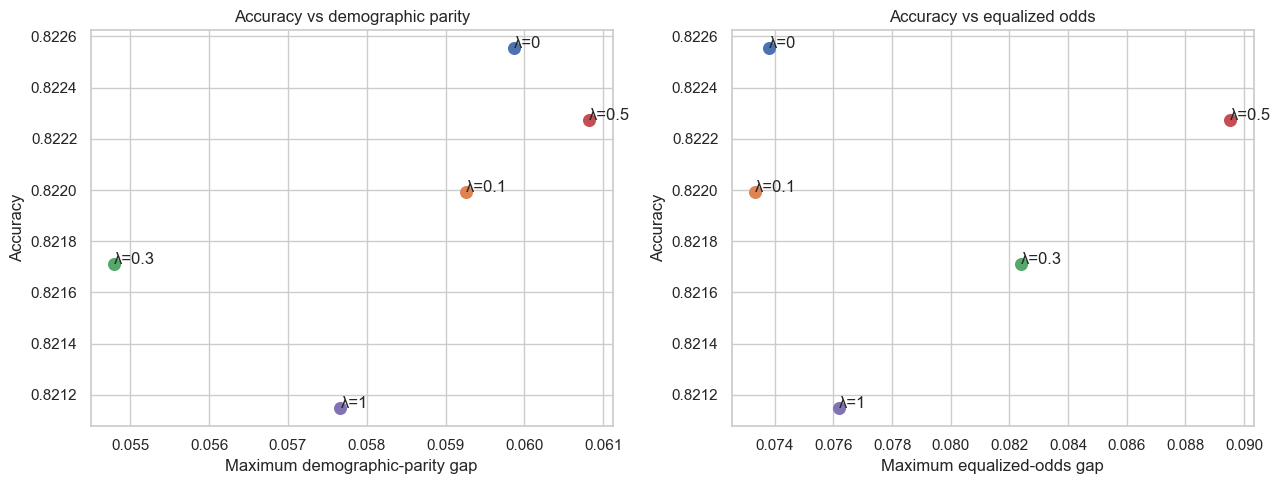

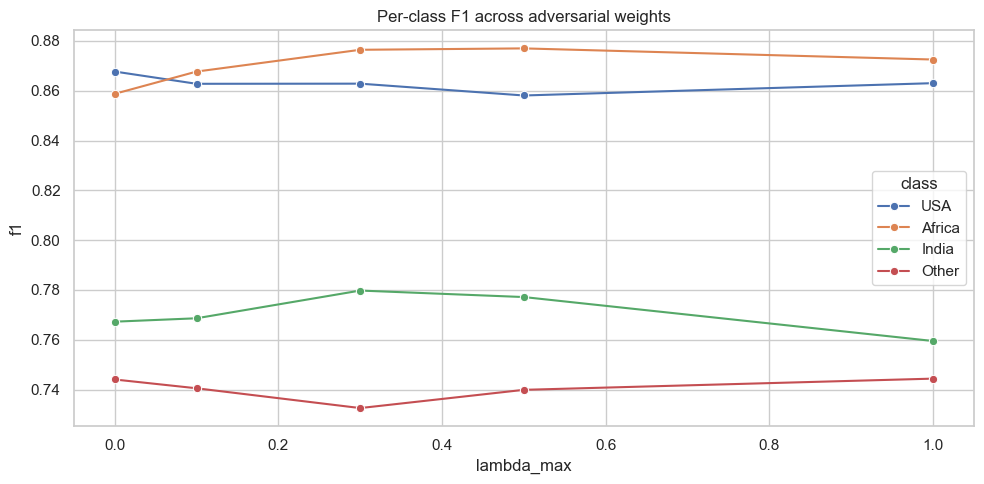

In [17]:
# Accuracy–fairness trade-off plots. Lower fairness gaps are better.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for _, row in tradeoff.iterrows():
    label = f"λ={row['lambda_max']:g}"
    axes[0].scatter(row["demographic_parity_gap"], row["accuracy"], s=70)
    axes[0].annotate(label, (row["demographic_parity_gap"], row["accuracy"]))
    axes[1].scatter(row["equalized_odds_gap"], row["accuracy"], s=70)
    axes[1].annotate(label, (row["equalized_odds_gap"], row["accuracy"]))
axes[0].set(xlabel="Maximum demographic-parity gap", ylabel="Accuracy", title="Accuracy vs demographic parity")
axes[1].set(xlabel="Maximum equalized-odds gap", ylabel="Accuracy", title="Accuracy vs equalized odds")
plt.tight_layout()
plt.show()

# Per-class F1 makes class-specific utility loss visible.
f1_long = tradeoff.melt(
    id_vars=["model", "lambda_max"],
    value_vars=[f"f1_{name}" for name in CLASS_NAMES],
    var_name="class", value_name="f1",
)
f1_long["class"] = f1_long["class"].str.removeprefix("f1_")
plt.figure(figsize=(10, 5))
sns.lineplot(data=f1_long, x="lambda_max", y="f1", hue="class", marker="o")
plt.title("Per-class F1 across adversarial weights")
plt.tight_layout()
plt.show()


In [18]:
# Save all summary and classwise results. Do not choose λ from test results;
# use this test sweep for reporting after the candidate set was fixed.
tradeoff_path = OUTPUT_DIR / "v3_accuracy_fairness_tradeoff.csv"
details_path = OUTPUT_DIR / "v3_classwise_fairness.csv"
tradeoff.to_csv(tradeoff_path, index=False)
fairness_by_class.to_csv(details_path, index=False)
for lambda_max, history in histories.items():
    history.to_csv(
        OUTPUT_DIR / f"history_lambda_{str(lambda_max).replace('.', '_')}.csv",
        index=False,
    )
print("Saved:", tradeoff_path)
print("Saved:", details_path)


Saved: D:\work\extra\diversification\project\outputs\ethnicity_v3_gender_debiasing\v3_accuracy_fairness_tradeoff.csv
Saved: D:\work\extra\diversification\project\outputs\ethnicity_v3_gender_debiasing\v3_classwise_fairness.csv
